# Raman PC-LDA

This notebook performs PC-LDA on `raman_adata` only (no single-cell RNA part), and generates:
- PC-LDA scatter plot (train/test)
- One-vs-rest ROC curves per cell type
- A confusion-style summary table (Members, Correct, and predicted counts)

In [98]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

In [99]:
raman_adata = sc.read_h5ad("./data/raman_B.h5ad")
raman_adata

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'

In [100]:
def _get_dense_X(adata):
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()
    return X

def pclda_train_test(adata, group="cell_type", percent=98, test_size=0.2, random_state=42, scale=True):
    X = _get_dense_X(adata)
    y = adata.obs[group].astype(str).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = None
    if scale:
        scaler = StandardScaler(with_mean=True)
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    pca = PCA()
    X_train_pca = pca.fit_transform(X_train)
    cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
    nPCs = np.searchsorted(cum_var, percent) + 1

    X_train_pca = X_train_pca[:, :nPCs]
    X_test_pca = pca.transform(X_test)[:, :nPCs]

    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_pca, y_train)

    X_train_lda = lda.transform(X_train_pca)
    X_test_lda = lda.transform(X_test_pca)

    y_pred = lda.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)

    # Probabilities for ROC (one-vs-rest)
    y_proba = lda.predict_proba(X_test_pca)

    U_train = pd.DataFrame(X_train_lda, columns=[f"LDA_{i+1}" for i in range(X_train_lda.shape[1])])
    U_train["group"] = y_train
    U_test = pd.DataFrame(X_test_lda, columns=[f"LDA_{i+1}" for i in range(X_test_lda.shape[1])])
    U_test["group"] = y_test

    return {
        "U_train": U_train,
        "U_test": U_test,
        "acc": acc,
        "lda": lda,
        "pca": pca,
        "scaler": scaler,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "classes": lda.classes_,
        "n_pcs": nPCs,
    }

In [101]:
from pathlib import Path
res = pclda_train_test(raman_adata, group="cell_type", percent=98, test_size=0.2, random_state=42, scale=True)
print(f'PCs retained: {res["n_pcs"]}')
print(f'Test accuracy: {res["acc"]:.4f}')

U_train = res["U_train"]
U_test = res["U_test"]

output_dir = Path("./results/figure1")
output_dir.mkdir(parents=True, exist_ok=True)

output_dir_s2 = Path("./results/figureS2")
output_dir_s2.mkdir(parents=True, exist_ok=True)

classes = res["classes"]
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
class_color_map = {cls: colors[i] for i, cls in enumerate(classes)}

PCs retained: 95
Test accuracy: 0.9470


In [102]:
def plot_pclda(U_train, U_test, class_color_map, dims=(1, 2), title="PC-LDA Visualization", output_dir=None, fname="pclda"):
    fig = plt.figure(figsize=(10, 8))
    unique_groups = U_train["group"].unique()

    if len(dims) == 2:
        ax = fig.add_subplot(111)
        for group in unique_groups:
            g_train = U_train[U_train["group"] == group]
            g_test = U_test[U_test["group"] == group]
            color = class_color_map.get(group, "gray")
            ax.scatter(g_train[f"LDA_{dims[0]}"] , g_train[f"LDA_{dims[1]}"] , label=f"Train: {group}", color=color, alpha=0.7)
            ax.scatter(g_test[f"LDA_{dims[0]}"] , g_test[f"LDA_{dims[1]}"] , label=f"Test: {group}", color=color, edgecolor="k", alpha=0.9, linewidth=1.5)
        ax.set_xlabel(f"LDA {dims[0]}")
        ax.set_ylabel(f"LDA {dims[1]}")
    else:
        raise ValueError("Only 2D plotting is supported in this notebook cell.")

    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    fig.tight_layout()

    if output_dir is not None:
        pdf_path = output_dir / f"{fname}.pdf"
        svg_path = output_dir / f"{fname}.svg"
        png_path = output_dir / f"{fname}.png"
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        fig.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

    plt.show()

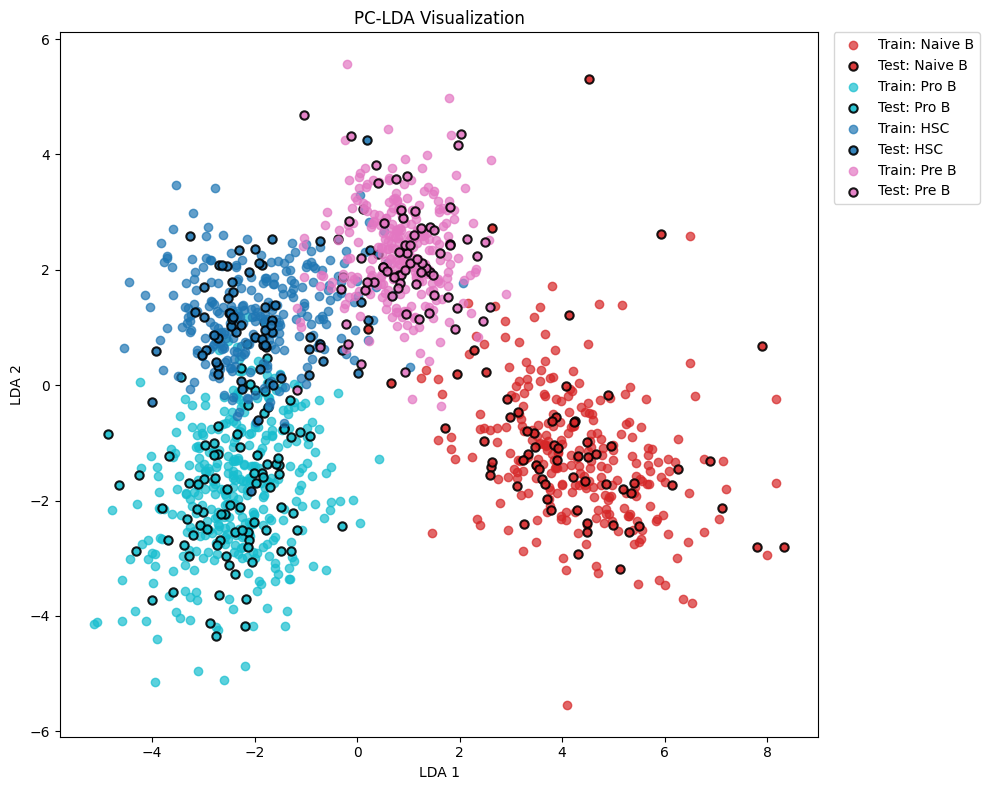

In [103]:
plot_pclda(U_train, U_test, class_color_map=class_color_map, dims=(1, 2), title="PC-LDA Visualization", output_dir=output_dir, fname="pclda")

## Additional Visualizations\n
\n
The plots below use all samples (train+test) in the LDA space and color by cell type only.\n

In [ ]:
# Merge train/test for class-only plots
U_all = pd.concat([U_train, U_test], axis=0, ignore_index=True)

def plot_lda_scatter(U, class_color_map, dims=(1, 2), title="LDA Scatter", output_dir=None, fname="lda_scatter"):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111)
    for cls in sorted(U["group"].unique()):
        data = U[U["group"] == cls]
        color = class_color_map.get(cls, "gray")
        ax.scatter(
            data[f"LDA_{dims[0]}"] , data[f"LDA_{dims[1]}"] ,
            s=14, alpha=0.7, color=color, label=cls
        )
    ax.set_xlabel(f"LDA {dims[0]}")
    ax.set_ylabel(f"LDA {dims[1]}")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    fig.tight_layout()

    if output_dir_s2 is not None:
        fig.savefig(output_dir_s2 / f"{fname}.pdf", format="pdf", bbox_inches="tight")
        fig.savefig(output_dir_s2 / f"{fname}.svg", format="svg", bbox_inches="tight")
        fig.savefig(output_dir_s2 / f"{fname}.png", format="png", dpi=300, bbox_inches="tight")

    plt.show()

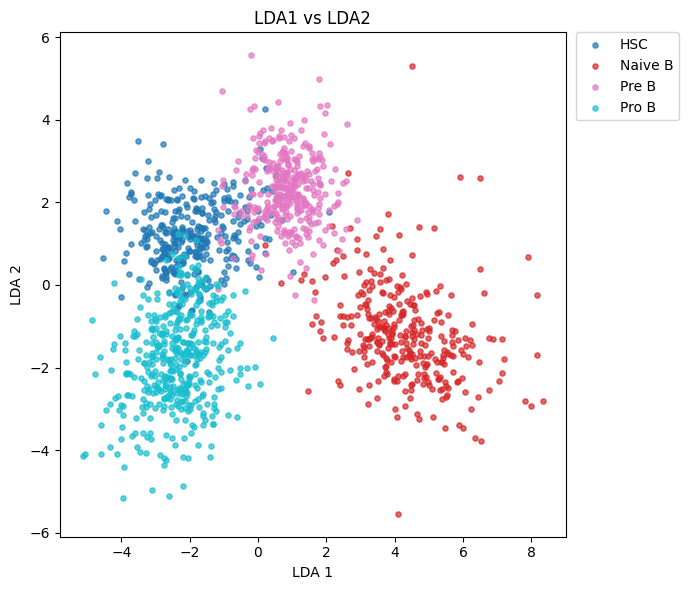

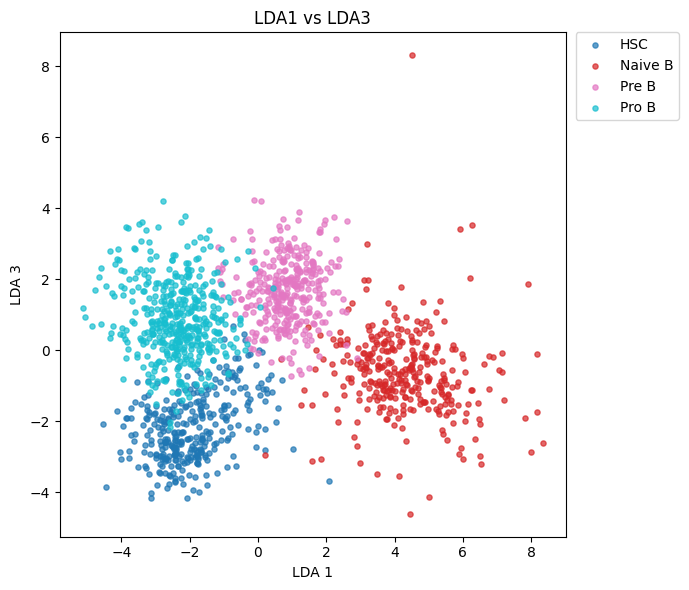

In [105]:
plot_lda_scatter(U_all, class_color_map, dims=(1, 2), title="LDA1 vs LDA2", output_dir=output_dir, fname="lda1_lda2")
plot_lda_scatter(U_all, class_color_map, dims=(1, 3), title="LDA1 vs LDA3", output_dir=output_dir, fname="lda1_lda3")

In [106]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def plot_lda_3d(U, class_color_map, title="LDA 3D", output_dir=None, fname="lda_3d"):
    fig = plt.figure(figsize=(15.8, 8.8))
    ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=20, azim=35)
    ax.set_box_aspect((1, 1, 0.8))
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    for cls in sorted(U["group"].unique()):
        data = U[U["group"] == cls]
        color = class_color_map.get(cls, "gray")
        ax.scatter(
            data["LDA_1"], data["LDA_2"], data["LDA_3"],
            s=14, alpha=0.75, color=color, label=cls, edgecolor="k", linewidth=0.2
        )

    ax.set_xlabel("LDA 1", labelpad=10)
    ax.set_ylabel("LDA 2", labelpad=14)
    ax.set_zlabel("LDA 3", labelpad=12)
    # Force label positions to be visible
    ax.xaxis.set_label_coords(0.85, -0.05)
    ax.yaxis.set_label_coords(-0.05, 0.2)
    ax.zaxis.set_label_coords(-0.08, 0.5)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    fig.subplots_adjust(left=0.10, right=0.82, top=0.92, bottom=0.08)

    if output_dir is not None:
        fig.savefig(output_dir / f"{fname}.pdf", format="pdf", bbox_inches="tight")
        fig.savefig(output_dir / f"{fname}.svg", format="svg", bbox_inches="tight")
        fig.savefig(output_dir / f"{fname}.png", format="png", dpi=300, bbox_inches="tight")

    plt.show()

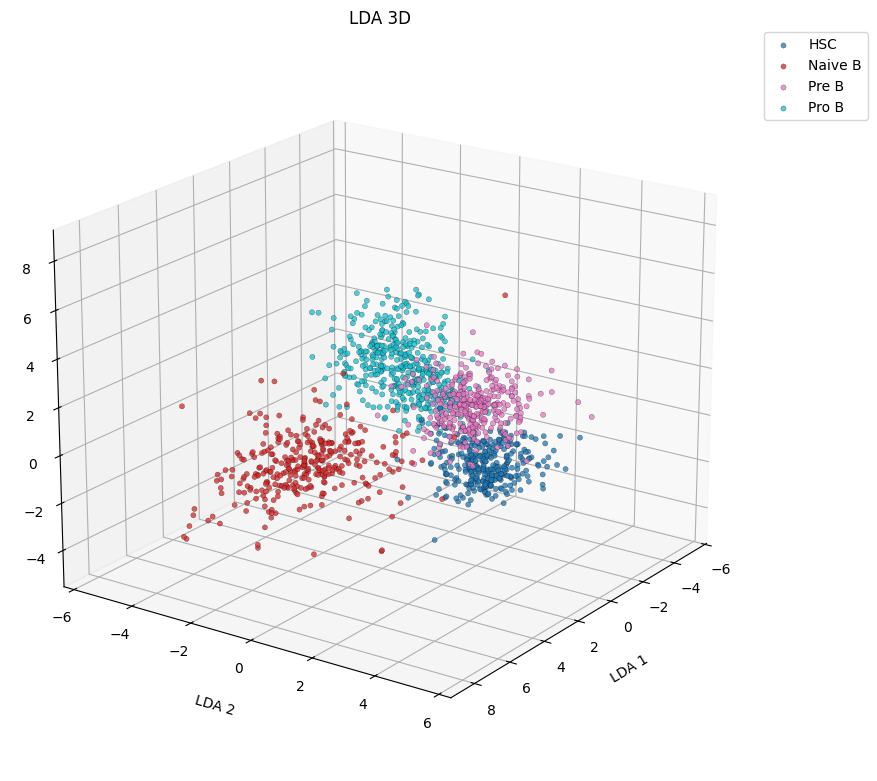

In [107]:
plot_lda_3d(U_all, class_color_map, title="LDA 3D", output_dir=output_dir_s2, fname="lda_3d")

## UMAP on LDA Space\n
\n
UMAP can be applied to the LDA feature space (LDA_1/2/3). This is valid and often used as a visualization,\n
but note it compresses an already supervised low-dimensional space. If you want UMAP on raw Raman features or PCA\n
features instead, let me know.\n

In [108]:
try:
    import umap
except Exception as e:
    raise ImportError("umap-learn is required. Install with: pip install umap-learn") from e

def plot_umap_from_lda(U, class_color_map, title="UMAP (from LDA)", output_dir=None, fname="umap_lda"):
    X = U[["LDA_1", "LDA_2", "LDA_3"]].values
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
    emb = reducer.fit_transform(X)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111)
    for cls in sorted(U["group"].unique()):
        idx = (U["group"] == cls).values
        color = class_color_map.get(cls, "gray")
        ax.scatter(emb[idx, 0], emb[idx, 1], s=14, alpha=0.7, color=color, label=cls)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    fig.tight_layout()

    if output_dir is not None:
        fig.savefig(output_dir / f"{fname}.pdf", format="pdf", bbox_inches="tight")
        fig.savefig(output_dir / f"{fname}.svg", format="svg", bbox_inches="tight")
        fig.savefig(output_dir / f"{fname}.png", format="png", dpi=300, bbox_inches="tight")

    plt.show()

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


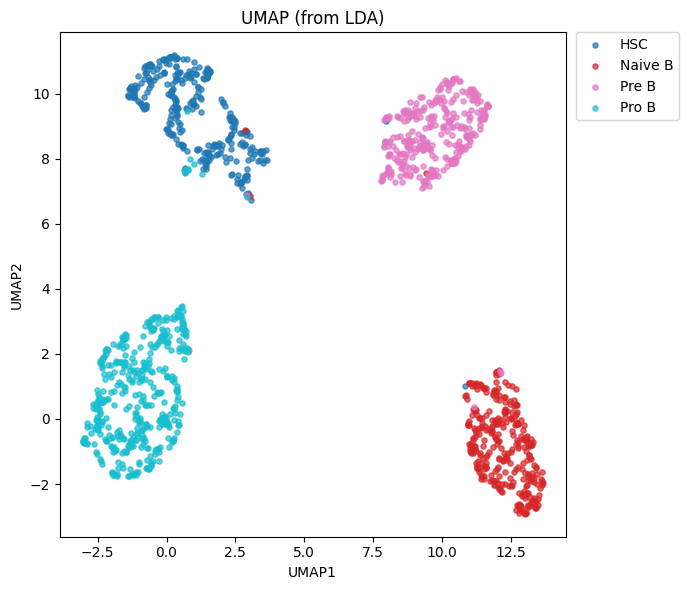

In [109]:
plot_umap_from_lda(U_all, class_color_map, title="UMAP (from LDA)", output_dir=output_dir_s2, fname="umap_lda")

In [110]:
def plot_roc_by_class(y_true, y_proba, classes, class_color_map, output_dir=None, fname="roc"):
    y_bin = label_binarize(y_true, classes=classes)
    fig = plt.figure(figsize=(8, 6))

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        color = class_color_map.get(cls, None)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})", color=color)

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC Curves")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    fig.tight_layout()

    if output_dir is not None:
        pdf_path = output_dir / f"{fname}.pdf"
        svg_path = output_dir / f"{fname}.svg"
        png_path = output_dir / f"{fname}.png"
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        fig.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

    plt.show()

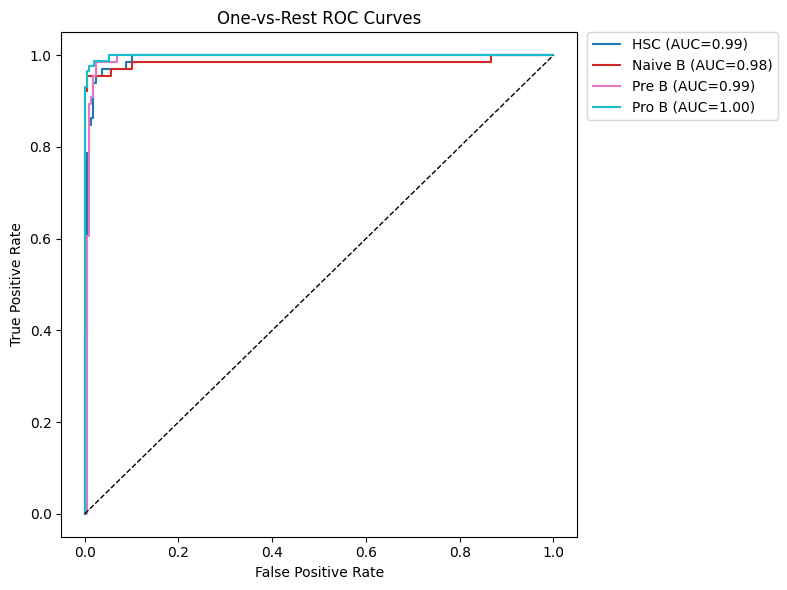

In [111]:
plot_roc_by_class(res["y_test"], res["y_proba"], res["classes"], class_color_map, output_dir=output_dir, fname="roc")

In [112]:
def build_confusion_table(y_true, y_pred, classes):
    ct = pd.crosstab(pd.Series(y_true, name="Actual"), pd.Series(y_pred, name="Predicted"))
    ct = ct.reindex(index=classes, columns=classes, fill_value=0)

    members = ct.sum(axis=1)
    correct = np.diag(ct)
    correct_pct = (correct / members * 100).round(2)

    summary = ct.copy()
    summary.insert(0, "Members", members)
    summary.insert(1, "Correct", [f"{p:.2f}%" for p in correct_pct])

    total_members = members.sum()
    total_correct = correct.sum()
    total_pct = (total_correct / total_members * 100) if total_members > 0 else 0.0
    total_row = [total_members, f"{total_pct:.2f}%"] + ct.sum(axis=0).tolist()

    summary.loc["Total"] = total_row
    return summary

def export_confusion_to_word(df, path):
    try:
        from docx import Document
    except Exception as e:
        raise ImportError("python-docx is required to export to Word. Install with: pip install python-docx") from e

    doc = Document()
    doc.add_heading("PC-LDA Confusion Summary", level=1)
    table = doc.add_table(rows=1, cols=len(df.columns) + 1)
    hdr = table.rows[0].cells
    hdr[0].text = "Actual"
    for j, col in enumerate(df.columns, start=1):
        hdr[j].text = str(col)

    for idx, row in df.iterrows():
        cells = table.add_row().cells
        cells[0].text = str(idx)
        for j, col in enumerate(df.columns, start=1):
            cells[j].text = str(row[col])

    doc.save(path)

In [113]:
conf_table = build_confusion_table(res["y_test"], res["y_pred"], res["classes"])
conf_table

word_path = output_dir / "confusion_table.docx"
export_confusion_to_word(conf_table, word_path)